In [1]:
import pandas as pd

In [2]:
encoding_data = pd.read_csv(r"C:\Users\apkar\OneDrive\Documents\iGEM\Head\Linker design\Substrate_encoding.csv")

In [ ]:
encoding_data.drop(['Unnamed: 0.1',	'Unnamed: 0'],inplace=True,axis = 1)
encoding_data.columns

In [9]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)


# ============================================================
# FEATURES AND TARGET
# ============================================================

# Get the 640 ESM-2 encoding columns
encoding_columns = [
    col for col in encoding_data.columns
    if col.startswith("Encoding_diamension")
]

X = encoding_data[encoding_columns]

# Target
y = encoding_data["Enzyme"]


# ============================================================
# ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Enzyme classes:")

for i, enzyme in enumerate(label_encoder.classes_):
    print(f"{i} = {enzyme}")


# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.40,
    random_state=42,
    stratify=y_encoded
)

print("\nDataset:")
print("Total samples:", len(X))

print("\nTraining:")
print("Samples:", len(X_train))

print("\nTesting:")
print("Samples:", len(X_test))

print("\nFeatures:", X_train.shape[1])


# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed.")

Enzyme classes:
0 = Aspartic
1 = Serine

Class distribution:
Enzyme
Aspartic    4541
Serine      3758
Name: count, dtype: int64

Class percentages:
Enzyme
Aspartic    54.717436
Serine      45.282564
Name: proportion, dtype: float64

Dataset:
Total samples: 8299

Training:
Samples: 4979

Testing:
Samples: 3320

Features: 640

Scaling completed.


LOGISTIC REGRESSION
Accuracy : 0.7545
ROC-AUC  : 0.8300

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.77      0.79      0.78      1817
      Serine       0.74      0.71      0.72      1503

    accuracy                           0.75      3320
   macro avg       0.75      0.75      0.75      3320
weighted avg       0.75      0.75      0.75      3320



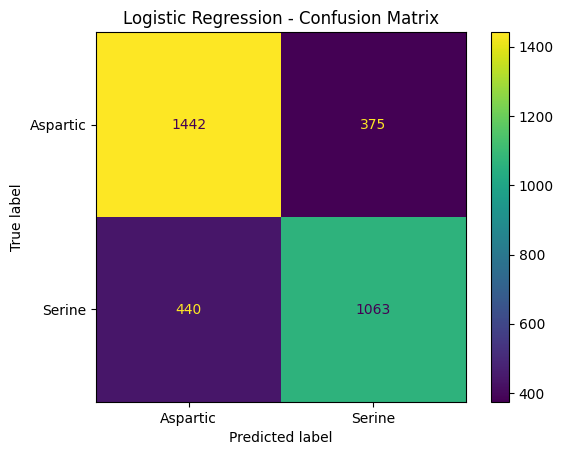

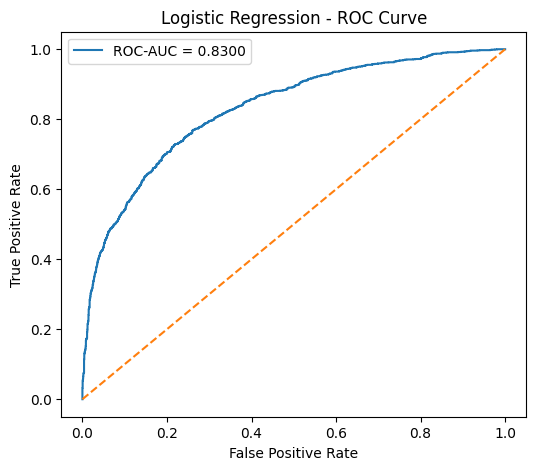

In [10]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)


# Predictions
y_pred = logistic_model.predict(X_test_scaled)

# Probability of Serine (class 1)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


print("LOGISTIC REGRESSION")
print("===================")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression - ROC Curve")

plt.legend()
plt.show()

SVM
===
Accuracy : 0.7687
ROC-AUC  : 0.8438

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.76      0.85      0.80      1817
      Serine       0.79      0.67      0.72      1503

    accuracy                           0.77      3320
   macro avg       0.77      0.76      0.76      3320
weighted avg       0.77      0.77      0.77      3320



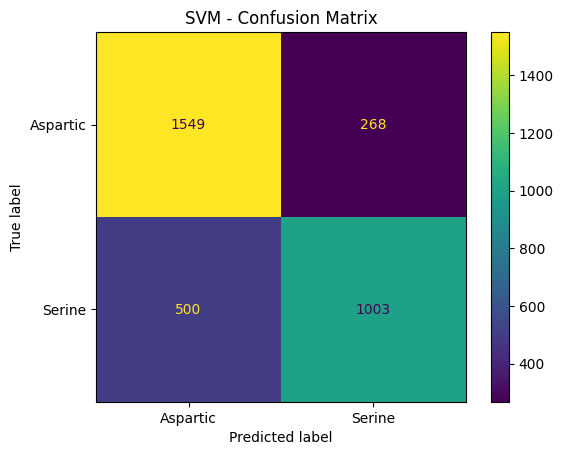

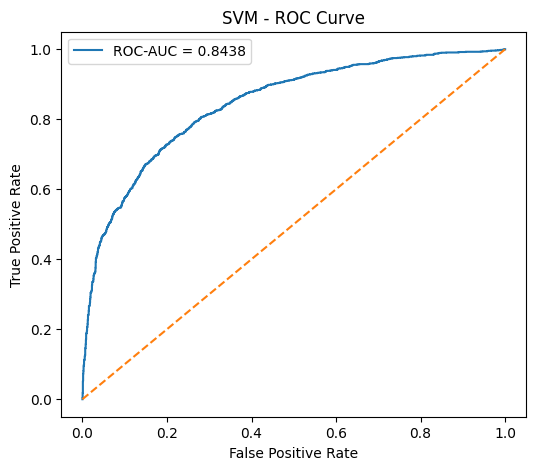

In [11]:
# ============================================================
# SVM
# ============================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)


# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Decision score
y_score = svm_model.decision_function(X_test_scaled)


# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)


print("SVM")
print("===")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("SVM - Confusion Matrix")
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_score
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM - ROC Curve")

plt.legend()
plt.show()

DECISION TREE
Accuracy : 0.6521
ROC-AUC  : 0.6124

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.67      0.70      0.69      1817
      Serine       0.62      0.59      0.61      1503

    accuracy                           0.65      3320
   macro avg       0.65      0.65      0.65      3320
weighted avg       0.65      0.65      0.65      3320



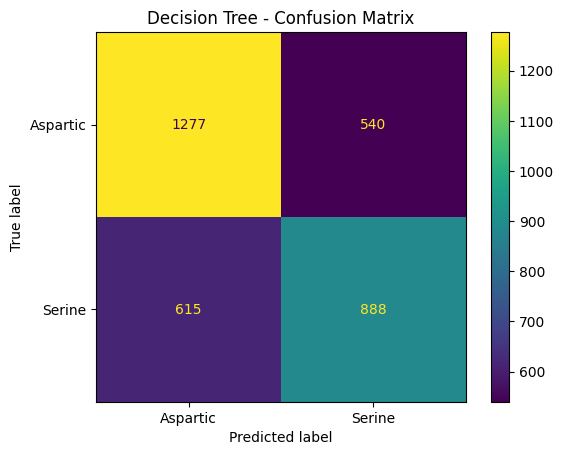

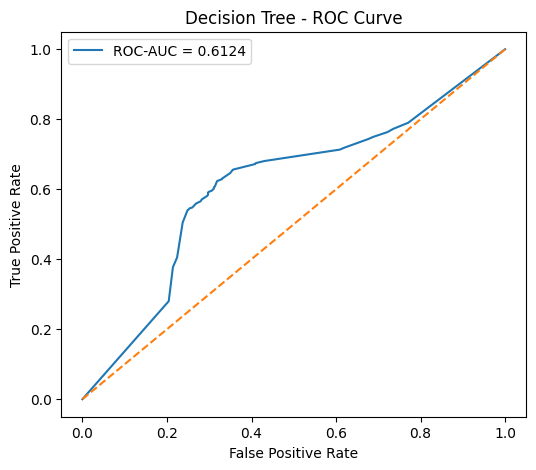

In [12]:
# ============================================================
# DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)


# Predictions
y_pred = dt_model.predict(X_test)

# Probability of class 1 = Serine
y_prob = dt_model.predict_proba(X_test)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


print("DECISION TREE")
print("=============")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree - ROC Curve")

plt.legend()
plt.show()

RANDOM FOREST
Accuracy : 0.7554
ROC-AUC  : 0.8301

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.74      0.84      0.79      1817
      Serine       0.77      0.65      0.71      1503

    accuracy                           0.76      3320
   macro avg       0.76      0.75      0.75      3320
weighted avg       0.76      0.76      0.75      3320



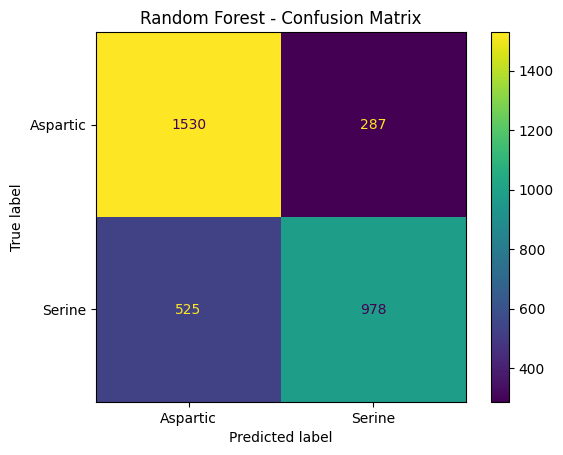

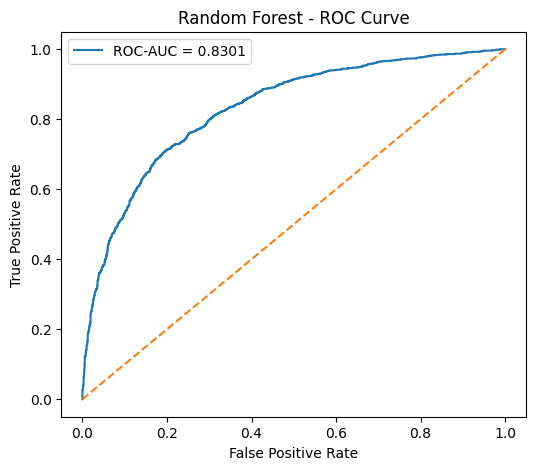

In [13]:
# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)


# Predictions
y_pred = rf_model.predict(X_test)

# Probability of class 1 = Serine
y_prob = rf_model.predict_proba(X_test)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


print("RANDOM FOREST")
print("=============")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest - ROC Curve")

plt.legend()
plt.show()

KNN
===
Accuracy : 0.7398
ROC-AUC  : 0.8141

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.73      0.82      0.78      1817
      Serine       0.75      0.64      0.69      1503

    accuracy                           0.74      3320
   macro avg       0.74      0.73      0.73      3320
weighted avg       0.74      0.74      0.74      3320



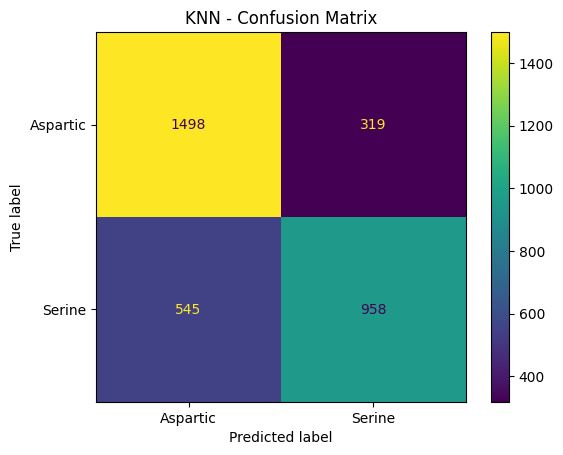

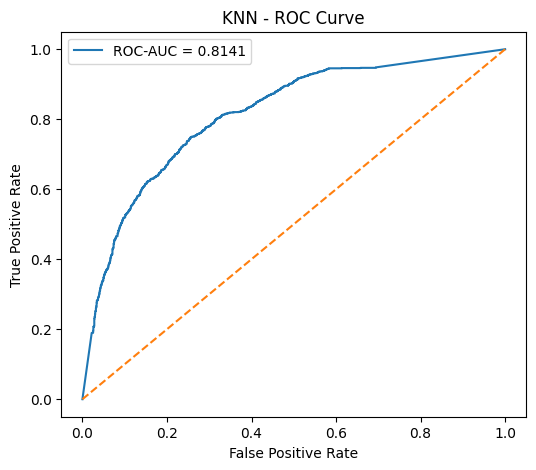

In [14]:
# ============================================================
# KNN
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

knn_model.fit(
    X_train_scaled,
    y_train
)


# Predictions
y_pred = knn_model.predict(X_test_scaled)

# Probability of class 1 = Serine
y_prob = knn_model.predict_proba(X_test_scaled)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


print("KNN")
print("===")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("KNN - Confusion Matrix")
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("KNN - ROC Curve")

plt.legend()
plt.show()

In [16]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 5.3 MB/s eta 0:00:10
   - -------------------------------------- 2.4/48.9 MB 5.6 MB/s eta 0:00:09
   -- ------------------------------------- 3.4/48.9 MB 5.6 MB/s eta 0:00:09
   --- ------------------------------------ 4.7/48.9 MB 5.6 MB/s eta 0:00:08
   ---- ----------------------------------- 5.8/48.9 MB 5.7 MB/s eta 0:00:08
   ----- ---------------------------------- 7.3/48.9 MB 5.8 MB/s eta 0:00:08
   ------- -------------------------------- 8.7/48.9 MB 5.8 MB/s eta 0:00:07
   -------- ------------------------------- 10.0/48.9 MB 5.9 MB/s eta 0:00:07
   -------- ------------------------------- 11.0/48.9 MB 5.9 MB/s eta 0:00:07
   ---------- ----------------------------- 12.3/48.9 MB 5.9 MB/s eta 0:00:07
   ----------- ---------------------------- 13.6/48.9 MB 5.9 MB/s eta 0:00:07
   ----------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBOOST
Accuracy : 0.7714
ROC-AUC  : 0.8420

Classification Report:
              precision    recall  f1-score   support

    Aspartic       0.77      0.84      0.80      1817
      Serine       0.78      0.69      0.73      1503

    accuracy                           0.77      3320
   macro avg       0.77      0.76      0.77      3320
weighted avg       0.77      0.77      0.77      3320



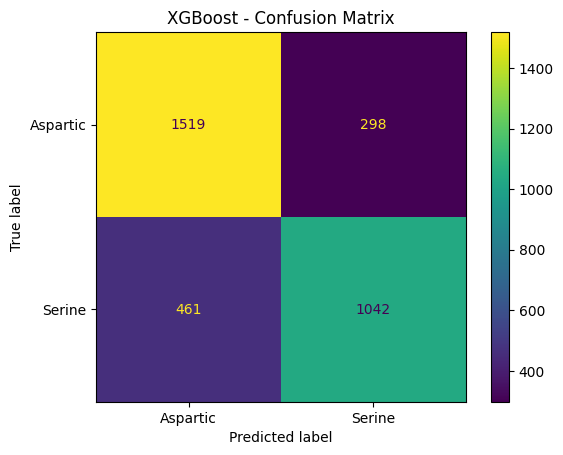

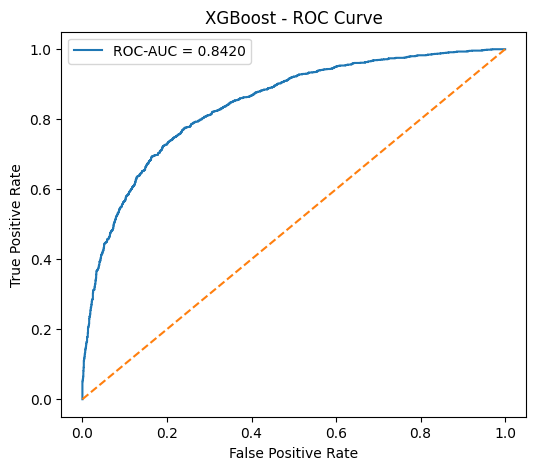

In [17]:
# ============================================================
# XGBOOST
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(
    X_train,
    y_train
)

# Predictions
y_pred = xgb_model.predict(X_test)

# Probability of class 1 = Serine
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("XGBOOST")
print("=======")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost - ROC Curve")

plt.legend()
plt.show()

In [18]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results = []

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_pred = logistic_model.predict(X_test_scaled)
lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

results.append([
    "Logistic Regression",
    accuracy_score(y_test, lr_pred),
    roc_auc_score(y_test, lr_prob)
])


# ------------------------------------------------------------
# SVM
# ------------------------------------------------------------

svm_pred = svm_model.predict(X_test_scaled)
svm_score = svm_model.decision_function(X_test_scaled)

results.append([
    "SVM",
    accuracy_score(y_test, svm_pred),
    roc_auc_score(y_test, svm_score)
])


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

results.append([
    "Decision Tree",
    accuracy_score(y_test, dt_pred),
    roc_auc_score(y_test, dt_prob)
])


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

results.append([
    "Random Forest",
    accuracy_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_prob)
])


# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

results.append([
    "KNN",
    accuracy_score(y_test, knn_pred),
    roc_auc_score(y_test, knn_prob)
])


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

results.append([
    "XGBoost",
    accuracy_score(y_test, xgb_pred),
    roc_auc_score(y_test, xgb_prob)
])


# ------------------------------------------------------------
# Create comparison DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,ROC-AUC
0,SVM,0.768675,0.843816
1,XGBoost,0.771386,0.842030
2,Random Forest,0.755422,0.830090
3,Logistic Regression,0.754518,0.829957
4,KNN,0.739759,0.814129
5,Decision Tree,0.652108,0.612384


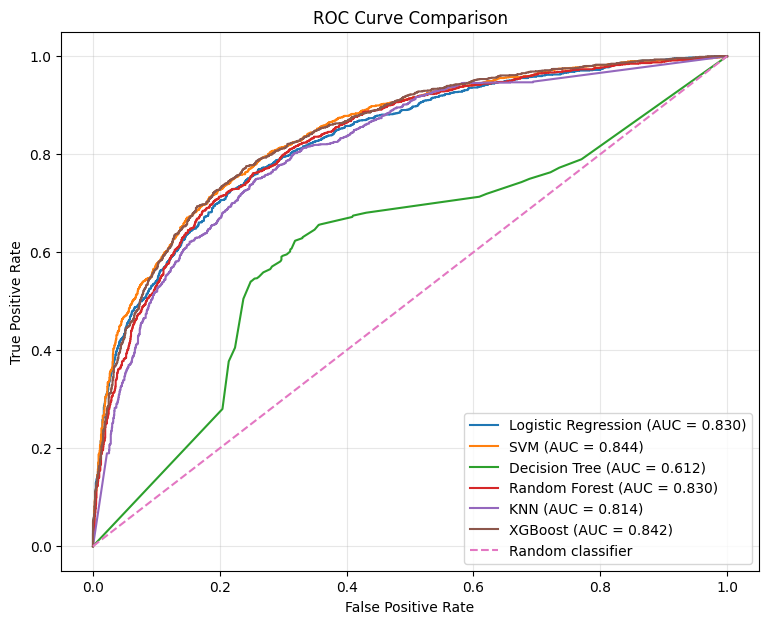

In [19]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(9, 7))


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc = roc_auc_score(y_test, lr_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# SVM
# ------------------------------------------------------------

svm_score = svm_model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, svm_score)
auc = roc_auc_score(y_test, svm_score)

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

dt_prob = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, dt_prob)
auc = roc_auc_score(y_test, dt_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc = roc_auc_score(y_test, rf_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, knn_prob)
auc = roc_auc_score(y_test, knn_prob)

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
auc = roc_auc_score(y_test, xgb_prob)

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc:.3f})"
)


# ------------------------------------------------------------
# Random classifier
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.show()

In [20]:
# ============================================================
# SAVE ALL MODELS
# ============================================================

import os
import joblib

# Create folder
save_folder = "Iteration 2"
os.makedirs(save_folder, exist_ok=True)


# Save models
joblib.dump(logistic_model, os.path.join(save_folder, "logistic_regression.pkl"))
joblib.dump(svm_model, os.path.join(save_folder, "svm.pkl"))
joblib.dump(dt_model, os.path.join(save_folder, "decision_tree.pkl"))
joblib.dump(rf_model, os.path.join(save_folder, "random_forest.pkl"))
joblib.dump(knn_model, os.path.join(save_folder, "knn.pkl"))
joblib.dump(xgb_model, os.path.join(save_folder, "xgboost.pkl"))


# Save preprocessing objects
joblib.dump(scaler, os.path.join(save_folder, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(save_folder, "label_encoder.pkl"))


print("All models saved successfully!")
print(f"Folder: {os.path.abspath(save_folder)}")

All models saved successfully!
Folder: c:\Users\apkar\OneDrive\Documents\iGEM\Head\Linker design\Iteration 2
